# Mixed frame/truss lattice tower workflow

This notebook solves the TE5 and Z5 tower-top models using a mixed stiffness-method model:

- **frame elements**: axial + shear + bending + torsion, 6 DOFs per node;
- **truss elements**: axial stiffness only, translational DOFs only;
- **bottom nodes**: fixed supports;
- **truss-only rotations**: automatically restrained because they are physically unused.

The important new switch is `CROSSING_DIAGONAL_MODE`, which controls how crossing truss diagonals are treated.


In [13]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()

if (CWD / "solver.py").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "solver.py").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Could not find solver.py. "
        "Expected it either in the current directory or one level above."
    )

# Make project root importable.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

#PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from solver import (
    read_model, read_loads_csv, SolveOptions, solve_model, summarize_result,
    critical_member_table, critical_member_table_matched_alternating,
    alternating_element_table, export_results_to_excel, export_result,
)
from helpers import (
    plot_geometry, plot_stress_3d, plot_signed_stress_3d, plot_deformed_shape,
    display_columns, select_elements, select_member_forces_for_elements,
)

## User-editable analysis options

`CROSSING_DIAGONAL_MODE` accepts exactly three modelling choices:

- `continuous`: crossing diagonals pass over/under each other. Split crossing nodes are removed from the analysis by merging the diagonal segments back into continuous bars.
- `connected_stabilized`: crossing diagonals are structurally connected at the inserted crossing node. Tiny stabilizing springs are added only along missing truss-only mechanism directions.
- `connected_unstabilized`: crossing diagonals are structurally connected, but no tiny springs are added. This is a useful diagnostic case. It is **not mathematically guaranteed** to be singular for every possible geometry, but in these current TE5/Z5 models it is expected to be singular because some crossing joints are truss-only planar mechanisms.

`SECTION_MODE` accepts:

- `principal`: calculated principal L-angle inertias;
- `isotropic`: simplified `Iy = Iz = Iavg`.


In [14]:
SECTION_MODE = 'principal'
PRINCIPAL_ORIENTATION = 'strong_inward'

# Try: 'continuous', 'connected_stabilized', or 'connected_unstabilized'
CROSSING_DIAGONAL_MODE = 'continuous'

TOP_N_CRITICAL = 12
DEFORMED_SHAPE_SCALE = 100.0

## Load case

Edit this list to experiment with vertical, longitudinal, transverse, or combined loading.

DOF/component convention:

- `Fx`: global X force, N
- `Fy`: global Y force, N
- `Fz`: global Z force, N
- `Mx`: moment about global X, N·mm
- `My`: moment about global Y, N·mm
- `Mz`: moment about global Z, N·mm


In [ ]:
# USER LOAD INPUT CELL
LOAD_CASE_BY_LABEL = [
    # Node label      Fx       Fy       Fz        Mx   My   Mz
    {'node_label': 'high_xneg', 'Fx': 17000.0, 'Fy': 2000.0, 'Fz': -23400.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
    {'node_label': 'high_xpos', 'Fx': 17000.0, 'Fy': 2000.0, 'Fz': -23400.0, 'Mx': 0.0, 'My': 0.0, 'Mz': 0.0},
]

LOAD_CASE_BY_LABEL

[{'node_label': 'high_xneg',
  'Fx': 17000.0,
  'Fy': 2000.0,
  'Fz': -13400.0,
  'Mx': 0.0,
  'My': 0.0,
  'Mz': 0.0},
 {'node_label': 'high_xpos',
  'Fx': 17000.0,
  'Fy': 2000.0,
  'Fz': -13400.0,
  'Mx': 0.0,
  'My': 0.0,
  'Mz': 0.0}]

## Load the models

In [16]:
models = {
    'TE5': read_model('TE5', DATA_DIR / 'TE5_nodes_aligned.csv', DATA_DIR / 'TE5_elements_with_sections.csv'),
    'Z5': read_model('Z5', DATA_DIR / 'Z5_nodes_aligned.csv', DATA_DIR / 'Z5_elements_with_sections.csv'),
}

for name, model in models.items():
    print(name, 'nodes =', len(model.nodes), 'elements =', len(model.elements))
    display(model.elements['element_type'].value_counts().rename('count').to_frame())

TE5 nodes = 44 elements = 110


,count
element_type,
truss,60
frame,50


Z5 nodes = 40 elements = 104


,count
element_type,
truss,56
frame,48


## Geometry check

The first plot shows all elements. The second plot shows frame elements only. This keeps the main frame topology readable while still allowing full-structure verification.


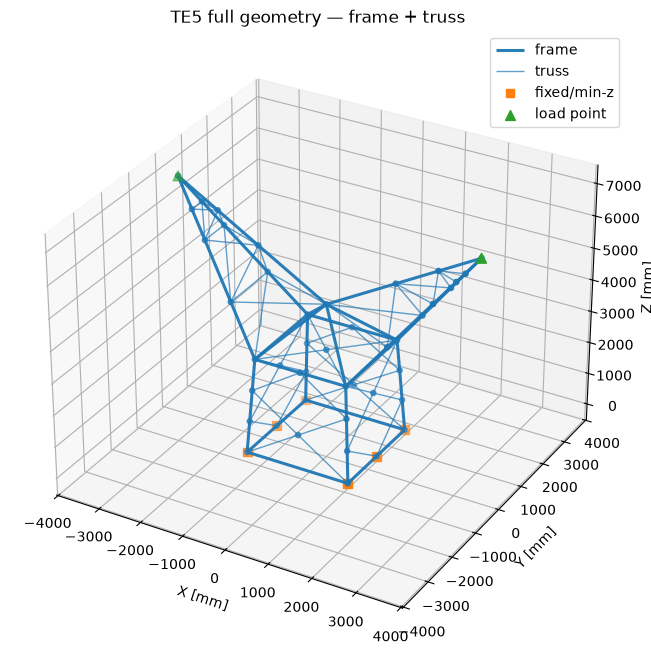

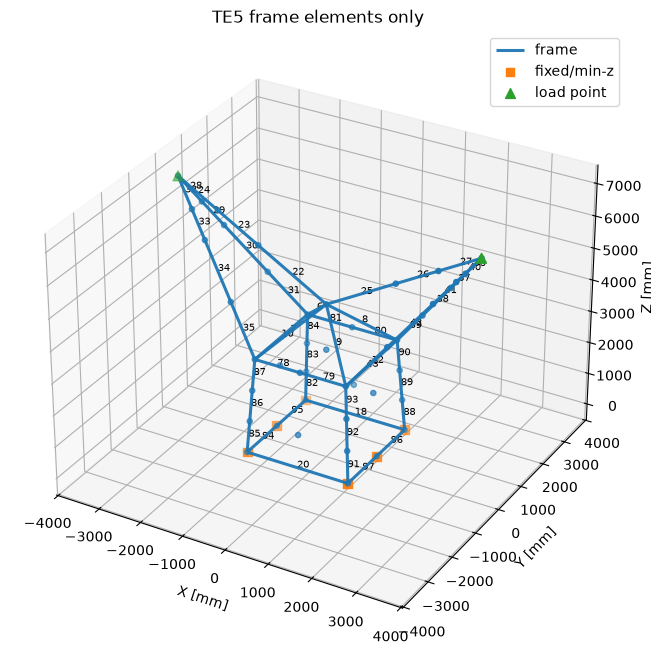

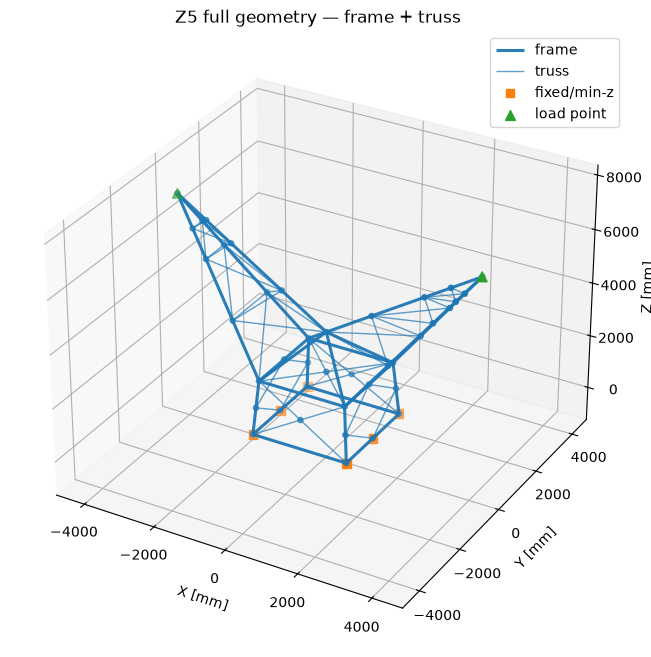

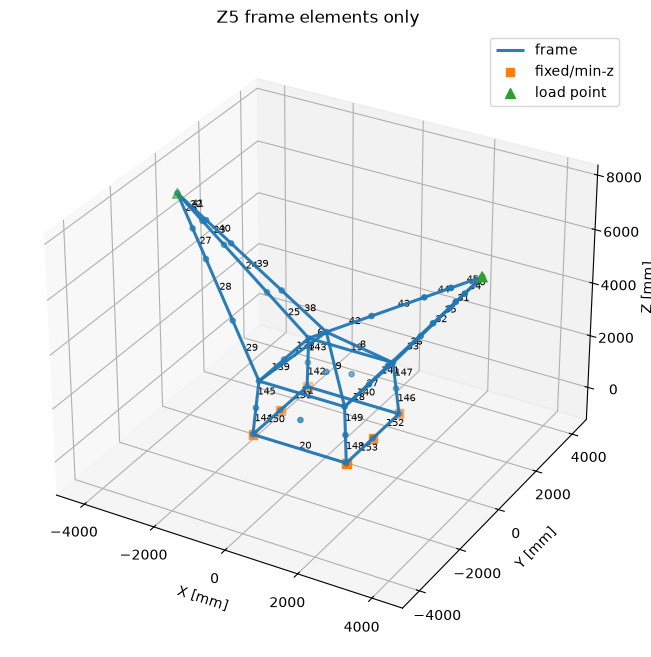

In [17]:
for name, model in models.items():
    fig, ax = plot_geometry(
        model.nodes, model.elements,
        title=f'{name} full geometry — frame + truss',
        annotate=False, annotate_elements=False, show_frame=True, show_truss=True,
    )
    plt.show()

    fig, ax = plot_geometry(
        model.nodes, model.elements,
        title=f'{name} frame elements only',
        annotate=False, annotate_elements=True, show_frame=True, show_truss=False,
    )
    plt.show()

## Solve selected crossing-diagonal mode

In [18]:
options = SolveOptions(
    crossing_diagonal_mode=CROSSING_DIAGONAL_MODE,
    section_mode=SECTION_MODE,
    principal_orientation=PRINCIPAL_ORIENTATION,
)

results = {}
for name, model in models.items():
    print(f'Solving {name} with crossing mode = {CROSSING_DIAGONAL_MODE!r} ...')
    results[name] = solve_model(model, LOAD_CASE_BY_LABEL, options)

summary = pd.DataFrame([summarize_result(res) for res in results.values()])
display(summary)

Solving TE5 with crossing mode = 'continuous' ...
Solving Z5 with crossing mode = 'continuous' ...


,model,crossing_diagonal_mode,section_mode,nodes,elements,frame_elements,truss_elements,restrained_dofs,free_dofs,reduced_stiffness_rank,max_translation_mm,max_abs_Uz_mm,max_abs_axial_force_kN,max_bending_resultant_kNmm,max_sigma_MPa
0,TE5,continuous,principal,39,100,50,50,36,198,198,8.296652,4.579291,57.762164,259.693505,59.481998
1,Z5,continuous,principal,37,98,48,50,36,186,186,9.956479,5.688043,66.090549,353.886988,72.808061


## Compare all three crossing-diagonal modes

This cell intentionally catches singular-matrix failures so the diagnostic mode can be evaluated without stopping the notebook.


In [19]:
mode_rows = []
mode_results = {}
for mode in ['continuous', 'connected_stabilized', 'connected_unstabilized']:
    mode_results[mode] = {}
    for name, model in models.items():
        try:
            res = solve_model(
                model, LOAD_CASE_BY_LABEL,
                SolveOptions(
                    crossing_diagonal_mode=mode,
                    section_mode=SECTION_MODE,
                    principal_orientation=PRINCIPAL_ORIENTATION,
                )
            )
            mode_results[mode][name] = res
            row = summarize_result(res)
            row['solve_status'] = 'OK'
            row['error'] = ''
        except Exception as exc:
            row = {
                'model': name,
                'crossing_diagonal_mode': mode,
                'section_mode': SECTION_MODE,
                'solve_status': 'FAILED',
                'error': f'{type(exc).__name__}: {exc}',
            }
        mode_rows.append(row)

mode_comparison = pd.DataFrame(mode_rows)
display(mode_comparison)
mode_comparison.to_csv(RESULTS_DIR / 'crossing_mode_comparison.csv', index=False)

,model,crossing_diagonal_mode,section_mode,nodes,elements,frame_elements,truss_elements,restrained_dofs,free_dofs,reduced_stiffness_rank,max_translation_mm,max_abs_Uz_mm,max_abs_axial_force_kN,max_bending_resultant_kNmm,max_sigma_MPa,solve_status,error
0,TE5,continuous,principal,39.0,100.0,50.0,50.0,36.0,198.0,198.0,8.296652,4.579291,57.762164,259.693505,59.481998,OK,
1,Z5,continuous,principal,37.0,98.0,48.0,50.0,36.0,186.0,186.0,9.956479,5.688043,66.090549,353.886988,72.808061,OK,
2,TE5,connected_stabilized,principal,44.0,110.0,50.0,60.0,51.0,213.0,213.0,8.296652,4.579291,57.762164,259.693505,59.481998,OK,
3,Z5,connected_stabilized,principal,40.0,104.0,48.0,56.0,45.0,195.0,195.0,9.956479,5.688043,66.090549,353.886988,72.808061,OK,
4,TE5,connected_unstabilized,principal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FAILED,LinAlgError: Reduced stiffness matrix is singu...
5,Z5,connected_unstabilized,principal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FAILED,LinAlgError: Reduced stiffness matrix is singu...


## Result tables

`Critical_Ranked` is sorted by stress within each model.

`Critical_Matched` takes the union of critical element IDs and displays TE5/Z5 rows next to each other by element ID, where possible.


In [20]:
DISPLAY_COLS = display_columns()

critical_ranked = critical_member_table(results, n=TOP_N_CRITICAL)
critical_matched = critical_member_table_matched_alternating(results, n=TOP_N_CRITICAL)
all_elements_alternating = alternating_element_table(results)

print('Critical ranked:')
display(critical_ranked[[c for c in DISPLAY_COLS if c in critical_ranked.columns]])

print('Critical matched / alternating:')
cols = [c for c in DISPLAY_COLS + ['in_top_n_for_model'] if c in critical_matched.columns]
display(critical_matched[cols])

print('All elements alternating:')
display(all_elements_alternating[[c for c in DISPLAY_COLS if c in all_elements_alternating.columns]])

Critical ranked:


,model,element_id,element_type,start_label,end_label,member_role,section_name,axial_state,sigma_extreme_signed_MPa,sigma_max_abs_MPa,sigma_axial_signed_MPa,axial_force_signed_N,max_abs_N_N,max_M_resultant_Nmm,stress_basis
0,TE5,26,frame,te5_e01_d2020_from_base,te5_e01_d3228_from_base,load_point_to_center,L90x90x7,tension,59.481998,59.481998,47.465492,57480.710811,57480.710811,118383.655331,frame axial+bending
1,TE5,27,frame,te5_e01_d3228_from_base,high_xpos,load_point_to_center,L90x90x7,tension,58.557539,58.557539,46.541034,56361.191771,56361.191771,118383.655331,frame axial+bending
2,TE5,36,frame,high_xpos,te5_e04_d4015_from_base,load_point_to_top,L90x90x7,compression,-51.950534,51.950534,-27.295203,-33054.490235,33054.490235,259693.504586,frame axial+bending
3,TE5,37,frame,te5_e04_d4015_from_base,te5_e04_d3185_from_base,load_point_to_top,L90x90x7,compression,-51.203396,51.203396,-27.334119,-33101.618606,33101.618606,259693.504586,frame axial+bending
4,TE5,25,frame,center,te5_e01_d2020_from_base,load_point_to_center,L90x90x7,tension,50.040864,50.040864,47.697906,57762.164480,57762.164480,23472.660569,frame axial+bending
5,TE5,88,frame,base_xpos_ypos,te5_e16_d986_from_bottom,leg,L102x102x7.9,compression,-44.991843,44.991843,-36.786604,-56989.438390,56989.438390,117196.083962,frame axial+bending
6,TE5,89,frame,te5_e16_d986_from_bottom,te5_e16_d975_from_top,leg,L102x102x7.9,compression,-40.438399,40.438399,-35.991052,-55756.978485,55756.978485,64728.593260,frame axial+bending
7,TE5,81,frame,te5_e13_mid,top_xneg_ypos,top_square_x_side,L76x64x4.8,compression,-39.637782,39.637782,-29.643509,-19237.451531,19237.451531,83814.003340,frame axial+bending
8,TE5,39,frame,te5_e04_d1530_from_base,top_xpos_ypos,load_point_to_top,L90x90x7,compression,-38.313954,38.313954,-27.667191,-33504.968678,33504.968678,172143.990118,frame axial+bending
9,TE5,7,frame,center,top_xneg_yneg,center_to_top,L90x90x7,tension,36.358824,36.358824,31.638702,38314.467877,38314.467877,47909.330833,frame axial+bending


Critical matched / alternating:


,model,element_id,element_type,start_label,end_label,member_role,section_name,axial_state,sigma_extreme_signed_MPa,sigma_max_abs_MPa,sigma_axial_signed_MPa,axial_force_signed_N,max_abs_N_N,max_M_resultant_Nmm,stress_basis,in_top_n_for_model
0,TE5,6,frame,center,top_xneg_ypos,center_to_top,L90x90x7,tension,35.585465,35.585465,31.610544,38280.368745,38280.368745,39692.521354,frame axial+bending,False
1,Z5,6,frame,center,top_xneg_ypos,center_to_top,L102x102x6.4,tension,39.671759,39.671759,33.441026,42290.859353,42290.859353,89446.568468,frame axial+bending,True
2,TE5,7,frame,center,top_xneg_yneg,center_to_top,L90x90x7,tension,36.358824,36.358824,31.638702,38314.467877,38314.467877,47909.330833,frame axial+bending,True
3,Z5,7,frame,center,top_xneg_yneg,center_to_top,L102x102x6.4,tension,40.632413,40.632413,33.471087,42328.875270,42328.875270,100780.642404,frame axial+bending,True
4,TE5,25,frame,center,te5_e01_d2020_from_base,load_point_to_center,L90x90x7,tension,50.040864,50.040864,47.697906,57762.164480,57762.164480,23472.660569,frame axial+bending,True
5,Z5,25,frame,z5_e02_top_xneg_ypos_d1942,top_xneg_ypos,load_point_to_top,L102x102x6.4,compression,-11.744020,11.744020,-2.878584,-3640.372530,3640.372530,218975.633328,frame axial+bending,False
6,TE5,26,frame,te5_e01_d2020_from_base,te5_e01_d3228_from_base,load_point_to_center,L90x90x7,tension,59.481998,59.481998,47.465492,57480.710811,57480.710811,118383.655331,frame axial+bending,True
7,Z5,26,frame,high_xneg,z5_e03_top_xneg_yneg_d4906,load_point_to_top,L102x102x6.4,tension,10.552541,10.552541,4.495069,5684.644356,5684.644356,72513.370023,frame axial+bending,False
8,TE5,27,frame,te5_e01_d3228_from_base,high_xpos,load_point_to_center,L90x90x7,tension,58.557539,58.557539,46.541034,56361.191771,56361.191771,118383.655331,frame axial+bending,True
9,Z5,27,frame,z5_e03_top_xneg_yneg_d4906,z5_e03_top_xneg_yneg_d3918,load_point_to_top,L102x102x6.4,tension,10.773088,10.773088,4.734248,5987.119031,5987.119031,72513.370023,frame axial+bending,False


All elements alternating:


,model,element_id,element_type,start_label,end_label,member_role,section_name,axial_state,sigma_extreme_signed_MPa,sigma_max_abs_MPa,sigma_axial_signed_MPa,axial_force_signed_N,max_abs_N_N,max_M_resultant_Nmm,stress_basis
0,TE5,6,frame,center,top_xneg_ypos,center_to_top,L90x90x7,tension,35.585465,35.585465,31.610544,38280.368745,38280.368745,39692.521354,frame axial+bending
1,Z5,6,frame,center,top_xneg_ypos,center_to_top,L102x102x6.4,tension,39.671759,39.671759,33.441026,42290.859353,42290.859353,89446.568468,frame axial+bending
2,TE5,7,frame,center,top_xneg_yneg,center_to_top,L90x90x7,tension,36.358824,36.358824,31.638702,38314.467877,38314.467877,47909.330833,frame axial+bending
3,Z5,7,frame,center,top_xneg_yneg,center_to_top,L102x102x6.4,tension,40.632413,40.632413,33.471087,42328.875270,42328.875270,100780.642404,frame axial+bending
4,TE5,8,frame,center,top_xpos_ypos,center_to_top,L90x90x7,compression,-23.129372,23.129372,-18.232270,-22079.278528,22079.278528,74241.461841,frame axial+bending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Z5,161,truss,z5_e17_mid,z5_e21_mid,lower_face_inscribed_xpos_bottom,L55x55x4,compression,-1.816016,1.816016,-1.816016,-769.990956,769.990956,0.000000,truss axial only
194,Z5,162,truss,z5_e10_mid,z5_e14_mid,lower_face_inscribed_xneg_top,L60x60x4,compression,-2.044126,2.044126,-2.044126,-948.474598,948.474598,0.000000,truss axial only
195,Z5,163,truss,z5_e10_mid,z5_e15_mid,lower_face_inscribed_xneg_top,L60x60x4,tension,2.136986,2.136986,2.136986,991.561306,991.561306,0.000000,truss axial only
196,Z5,164,truss,z5_e14_mid,z5_e19_mid,lower_face_inscribed_xneg_bottom,L55x55x4,tension,1.351451,1.351451,1.351451,573.015173,573.015173,0.000000,truss axial only


## Absolute stress visualization

This plot uses `sigma_max_abs_MPa`, so it shows magnitude only.


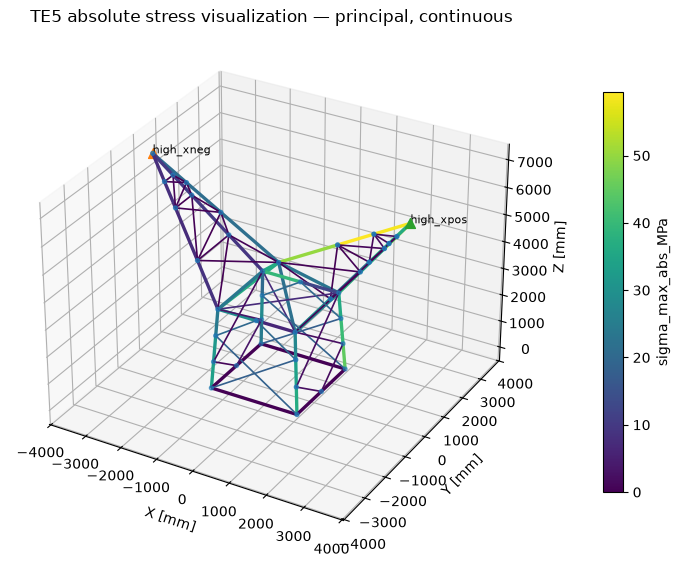

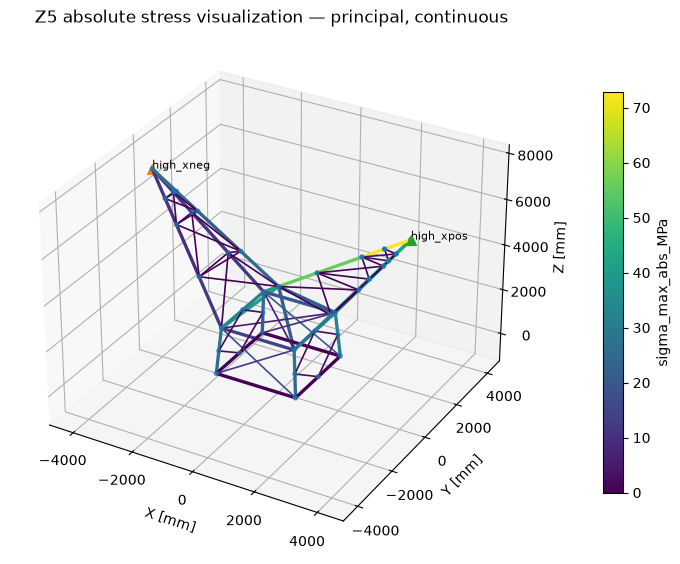

In [21]:
for name, res in results.items():
    fig, ax = plot_stress_3d(
        res['nodes'], res['elements'], res['member_forces'],
        title=f'{name} absolute stress visualization — {SECTION_MODE}, {CROSSING_DIAGONAL_MODE}',
        annotate_load_points=True, annotate_elements=False, show_frame=True, show_truss=True,
    )
    plt.show()

## Signed tension/compression visualization

Positive values are tensile; negative values are compressive.

By default this uses `sigma_extreme_signed_MPa`:

- for trusses: axial stress, signed;
- for frames: controlling extreme-fiber normal stress from axial + bending, signed.

For a pure axial-load-path plot, change `stress_column` to `sigma_axial_signed_MPa`.


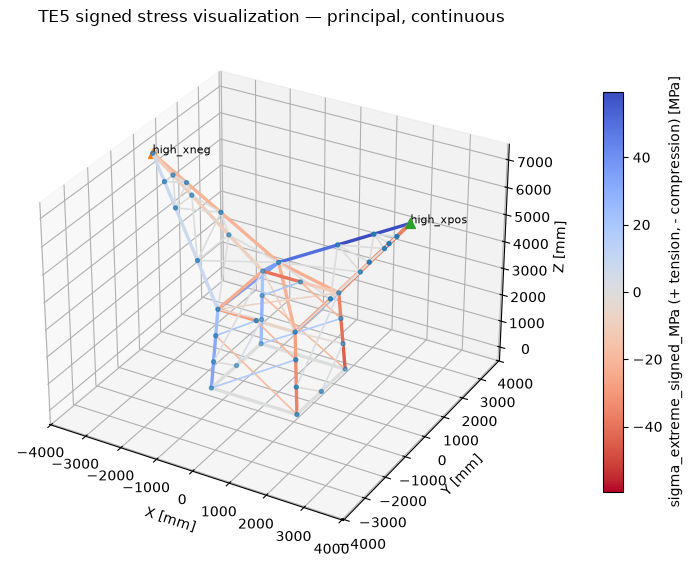

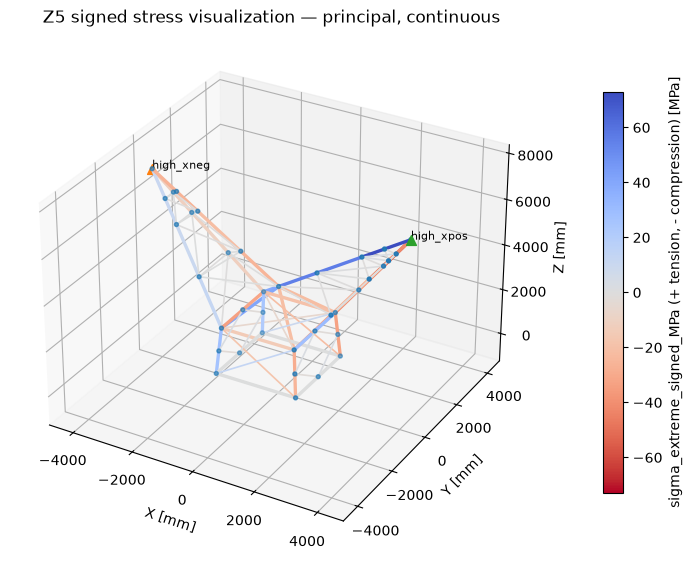

In [22]:
for name, res in results.items():
    fig, ax = plot_signed_stress_3d(
        res['nodes'], res['elements'], res['member_forces'],
        title=f'{name} signed stress visualization — {SECTION_MODE}, {CROSSING_DIAGONAL_MODE}',
        stress_column='sigma_extreme_signed_MPa',
        annotate_load_points=True, annotate_elements=False, show_frame=True, show_truss=True,
    )
    plt.show()

## Deformed shape

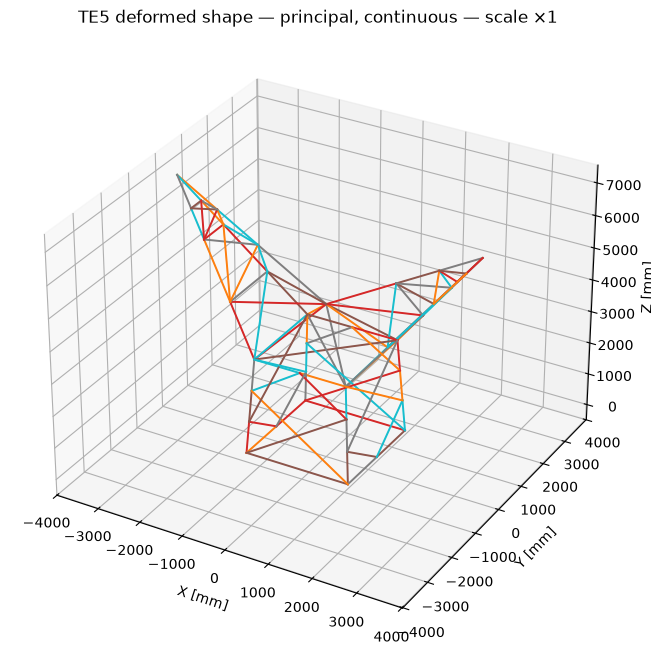

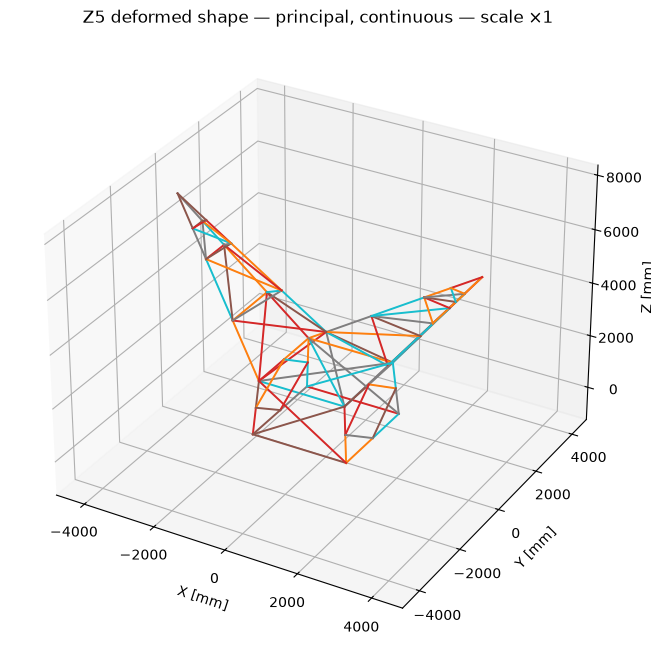

In [25]:
for name, res in results.items():
    fig, ax = plot_deformed_shape(
        res['nodes'], res['elements'], res['displacements'],
        scale=1,
        title=f'{name} deformed shape — {SECTION_MODE}, {CROSSING_DIAGONAL_MODE}',
        show_truss=True,
    )
    plt.show()

## Export results

The XLSX report includes summary sheets, critical ranked/matched tables, all elements in alternating order, and per-model result sheets.


In [24]:
out_xlsx = RESULTS_DIR / f'tower_results_{SECTION_MODE}_{CROSSING_DIAGONAL_MODE}.xlsx'
export_results_to_excel(results, out_xlsx, top_n=TOP_N_CRITICAL, display_columns=DISPLAY_COLS)

for name, res in results.items():
    export_result(res, RESULTS_DIR / 'csv_exports', prefix=f'{name}_{SECTION_MODE}_{CROSSING_DIAGONAL_MODE}')

print('Wrote:', out_xlsx)

Wrote: /workspaces/statiki/results/tower_results_principal_continuous.xlsx
